# Option 2: Stock Price Value Prediction - Regression

## Objective
Predict next day's stock price value using regression models

## Models Tested
- Linear Regression
- Decision Tree Regressor
- XGBoost Regressor
- Neural Network (TensorFlow)

In [69]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost tensorflow kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                            mean_absolute_percentage_error)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import kagglehub, os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

cwd = Path.cwd()
TASK_FOLDER = '02_stock_price_regression'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd

GRAPH_DIR = task_root / 'graph'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("[OK] All libraries loaded successfully")
print(f"[OK] Graph output folder: {GRAPH_DIR}")

Note: you may need to restart the kernel to use updated packages.
[OK] All libraries loaded successfully
[OK] Graph output folder: \\compdrive\Student5\25012923g\COMProfile\Desktop\Machine Learning project\project_folder\02_stock_price_regression\graph



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Data Loading & Exploration

In [70]:
# Download S&P 500 dataset
path = kagglehub.dataset_download("camnugent/sandp500")
files = os.listdir(path)
csv_file = [f for f in files if f.endswith(".csv")][0]
data = pd.read_csv(os.path.join(path, csv_file))

print(f"Dataset Shape: {data.shape}")
print(f"\nPrice Range: ${data['close'].min():.2f} - ${data['close'].max():.2f}")
print(f"Average Price: ${data['close'].mean():.2f}")
print(f"\nDate Range: {data['date'].min()} to {data['date'].max()}")

Dataset Shape: (619040, 7)

Price Range: $1.59 - $2049.00
Average Price: $83.04

Date Range: 2013-02-08 to 2018-02-07


## Step 2: Feature Engineering for Regression

In [71]:
# Select requested stocks and guarantee at least 5 symbols for project requirements
MIN_STOCKS = 5
requested_stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
all_symbols = data['Name'].value_counts().index.tolist()

# Keep requested stocks that exist in the dataset (preserve requested order)
available_requested = [s for s in requested_stocks if s in set(all_symbols)]
missing_stocks = [s for s in requested_stocks if s not in set(all_symbols)]

# Backfill with additional available symbols if requested set has fewer than MIN_STOCKS
needed = max(0, MIN_STOCKS - len(available_requested))
backup_stocks = [s for s in all_symbols if s not in available_requested][:needed]
top_stocks = available_requested + backup_stocks

if missing_stocks:
    print(f"[WARN] Missing requested tickers in dataset: {', '.join(missing_stocks)}")
if backup_stocks:
    print(f"[INFO] Added backup tickers to meet minimum {MIN_STOCKS}: {', '.join(backup_stocks)}")
if len(top_stocks) < MIN_STOCKS:
    print(f"[WARN] Dataset only provides {len(top_stocks)} unique symbols after filtering")

data_filtered = data[data['Name'].isin(top_stocks)].copy()
data_filtered = data_filtered.sort_values(['Name', 'date']).reset_index(drop=True)

def create_regression_features(stock_data):
    """Create features for stock price regression"""
    stock_data = stock_data.sort_values('date').reset_index(drop=True)
    
    # Target: Tomorrow's close price
    stock_data['target'] = stock_data['close'].shift(-1)
    
    # Price features
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['open']
    stock_data['close_open_diff'] = (stock_data['close'] - stock_data['open']) / stock_data['open']
    stock_data['high_low_ratio'] = stock_data['high'] / stock_data['low']
    
    # Returns
    stock_data['daily_return'] = stock_data['close'].pct_change()
    stock_data['lag_return_1'] = stock_data['daily_return'].shift(1)
    stock_data['lag_return_5'] = stock_data['close'].pct_change(5)
    
    # Volume features
    stock_data['volume_norm'] = stock_data['volume'] / stock_data['volume'].rolling(20).mean()
    stock_data['volume_trend'] = (stock_data['volume'] - stock_data['volume'].rolling(20).mean()) / stock_data['volume'].rolling(20).mean()
    
    # Moving averages
    stock_data['close_ma5'] = stock_data['close'].rolling(5).mean()
    stock_data['close_ma20'] = stock_data['close'].rolling(20).mean()
    stock_data['close_ma50'] = stock_data['close'].rolling(50).mean()
    
    # Price momentum
    stock_data['momentum_5'] = (stock_data['close'] - stock_data['close'].shift(5)) / stock_data['close'].shift(5)
    stock_data['momentum_20'] = (stock_data['close'] - stock_data['close'].shift(20)) / stock_data['close'].shift(20)
    
    # Volatility
    stock_data['volatility_20'] = stock_data['daily_return'].rolling(20).std()
    stock_data['volatility_60'] = stock_data['daily_return'].rolling(60).std()
    
    # RSI
    delta = stock_data['daily_return'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    stock_data['rsi'] = 100 - (100 / (1 + rs))
    
    # ADX-like trend strength
    stock_data['price_strength'] = abs(stock_data['close'] - stock_data['close'].shift(5)) / stock_data['close'].rolling(20).std()
    
    return stock_data

# Apply feature engineering
data_features = pd.concat([create_regression_features(data_filtered[data_filtered['Name'] == stock])
                           for stock in top_stocks], ignore_index=True)
data_features = data_features.dropna()

print(f"[OK] Using tickers ({len(top_stocks)}): {', '.join(top_stocks)}")
print(f"[OK] Features created. Dataset shape: {data_features.shape}")
print(f"\nTarget (Next Day Price) Statistics:")
print(data_features['target'].describe())

[OK] Using tickers (5): AAPL, MSFT, GOOGL, AMZN, NVDA
[OK] Features created. Dataset shape: (5990, 25)

Target (Next Day Price) Statistics:
count    5990.000000
mean      302.293410
std       320.701699
min        13.899000
25%        52.170000
50%       118.995000
75%       545.740000
max      1450.890000
Name: target, dtype: float64


## Step 3: Data Visualization

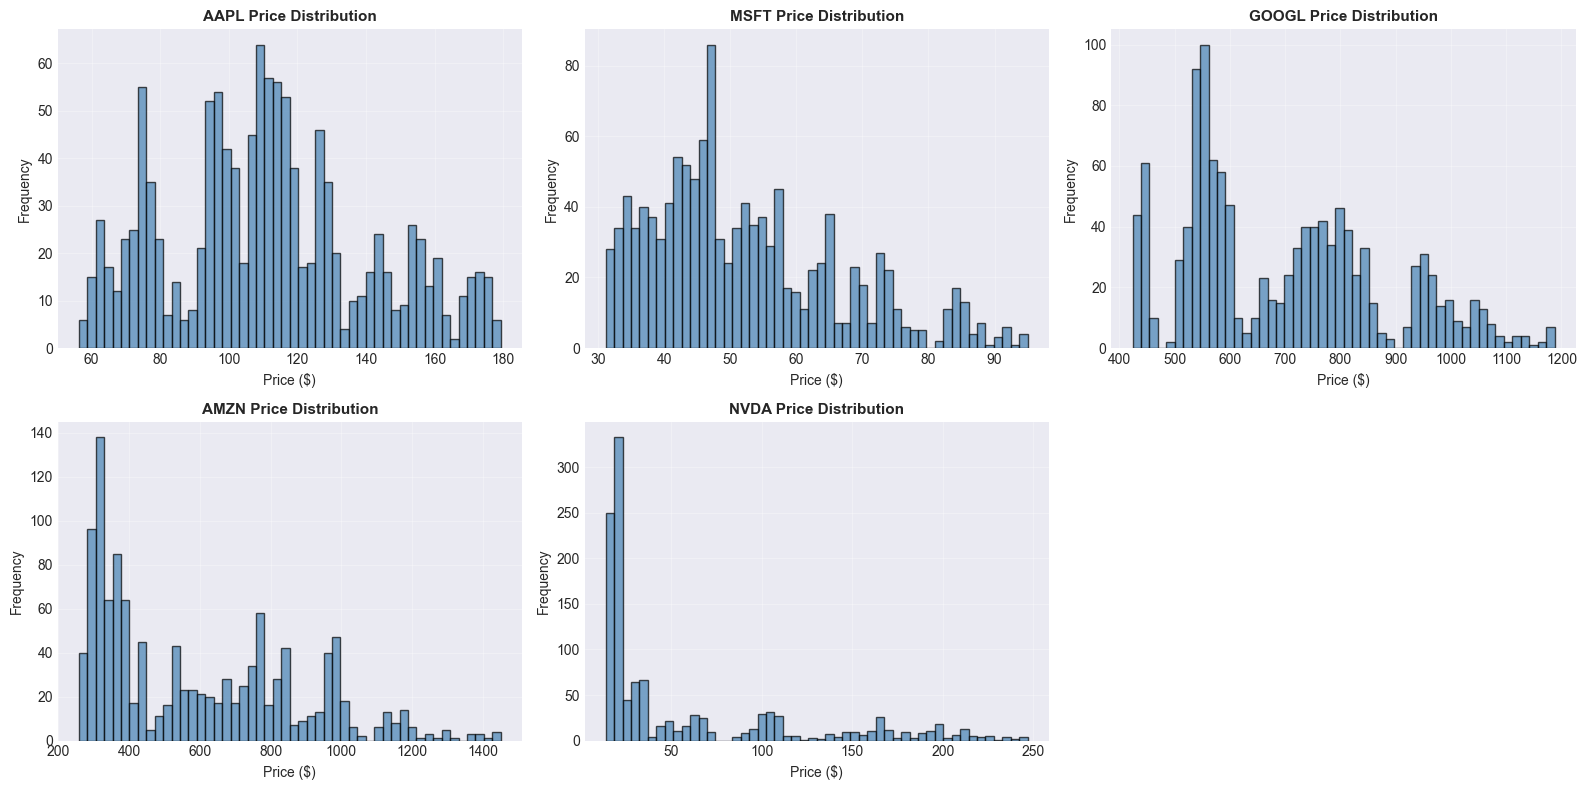

[OK] Saved: 01_price_distributions.png


In [72]:
# Price distributions by stock
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for idx, stock in enumerate(top_stocks):
    # Use a same-dataframe filter to avoid index alignment issues.
    stock_prices = data_features.loc[data_features['Name'] == stock, 'close'].dropna()
    if stock_prices.empty:
        stock_prices = data_filtered.loc[data_filtered['Name'] == stock, 'close'].dropna()

    if stock_prices.empty:
        axes[idx].text(0.5, 0.5, f'No data for {stock}', ha='center', va='center', fontsize=11)
        axes[idx].set_title(f'{stock} Price Distribution', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Price ($)')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)
        continue

    axes[idx].hist(stock_prices, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{stock} Price Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Price ($)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Hide any remaining unused subplot panels
for j in range(len(top_stocks), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '01_price_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 01_price_distributions.png")

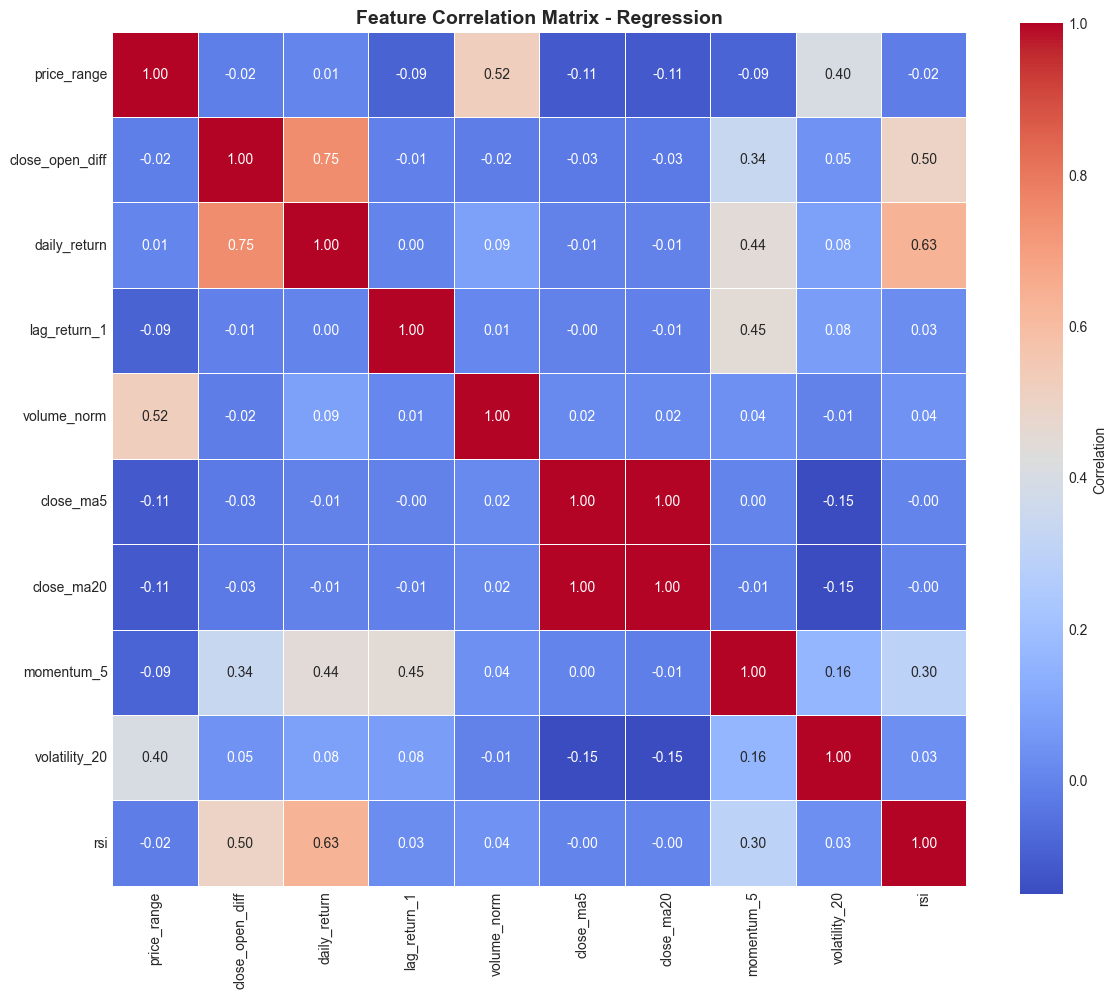

[OK] Saved: 02_feature_correlation_regression.png


In [73]:
# Feature correlation for regression
feature_cols = ['price_range', 'close_open_diff', 'daily_return', 'lag_return_1',
                'volume_norm', 'close_ma5', 'close_ma20', 'momentum_5',
                'volatility_20', 'rsi']

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = data_features[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            cbar_kws={'label': 'Correlation'}, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix - Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '02_feature_correlation_regression.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 02_feature_correlation_regression.png")

## Step 4: Data Preparation

In [74]:
# Prepare data
X = data_features[feature_cols].copy()
y = data_features['target'].copy()
X = X.fillna(X.mean())

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale targets for neural network
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print(f"\nTarget price range (Train): {y_train.min():.2f} - {y_train.max():.2f}")
print(f"Target price range (Test):  {y_test.min():.2f} - {y_test.max():.2f}")

Training set: 4792 samples | Test set: 1198 samples

Target price range (Train): 13.90 - 1437.82
Target price range (Test):  14.09 - 1450.89


## Step 5: Model Training

In [75]:
# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'model': model,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'r2': r2,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }
    
    print(f"MAE:   ${mae:.4f}")
    print(f"RMSE:  ${rmse:.4f}")
    print(f"MAPE:  {mape:.4f} ({mape*100:.2f}%)")
    print(f"R^2:   {r2:.4f}")
    print(f"CV R^2 (mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\n[OK] Traditional models trained!")


Training Linear Regression...
MAE:   $5.0849
RMSE:  $8.4799
MAPE:  0.0420 (4.20%)
R^2:   0.9992
CV R^2 (mean): 0.9993 (+/- 0.0001)

Training Decision Tree...
MAE:   $5.3512
RMSE:  $10.6675
MAPE:  0.0193 (1.93%)
R^2:   0.9988
CV R^2 (mean): 0.9990 (+/- 0.0001)

Training XGBoost...
MAE:   $4.2092
RMSE:  $8.9069
MAPE:  0.0160 (1.60%)
R^2:   0.9992
CV R^2 (mean): 0.9993 (+/- 0.0001)

[OK] Traditional models trained!


In [76]:
# Neural Network Model
print("\n" + "="*50)
print("Training Neural Network...")
print("="*50)

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

nn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = nn_model.fit(
    X_train_scaled, y_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

# Predict
y_pred_nn_scaled = nn_model.predict(X_test_scaled, verbose=0)
y_pred_nn = y_scaler.inverse_transform(y_pred_nn_scaled).ravel()

# Calculate metrics
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mape_nn = mean_absolute_percentage_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

results['Neural Network'] = {
    'model': nn_model,
    'mae': mae_nn,
    'rmse': rmse_nn,
    'mape': mape_nn,
    'r2': r2_nn,
    'cv_mean': None,
    'cv_std': None,
    'y_pred': y_pred_nn,
    'history': history
}

print(f"MAE:   ${mae_nn:.4f}")
print(f"RMSE:  ${rmse_nn:.4f}")
print(f"MAPE:  {mape_nn:.4f} ({mape_nn*100:.2f}%)")
print(f"R^2:   {r2_nn:.4f}")

print("\n[OK] All models trained successfully!")


Training Neural Network...
MAE:   $48.7452
RMSE:  $61.3004
MAPE:  0.7492 (74.92%)
R^2:   0.9606

[OK] All models trained successfully!


## Step 6: Performance Comparison


REGRESSION MODEL PERFORMANCE COMPARISON
                   MAE ($)  RMSE ($)  MAPE (%)  R^2 Score
Linear Regression   5.0849    8.4799    4.2022     0.9992
Decision Tree       5.3512   10.6675    1.9332     0.9988
XGBoost             4.2092    8.9069    1.5954     0.9992
Neural Network     48.7452   61.3004   74.9185     0.9606


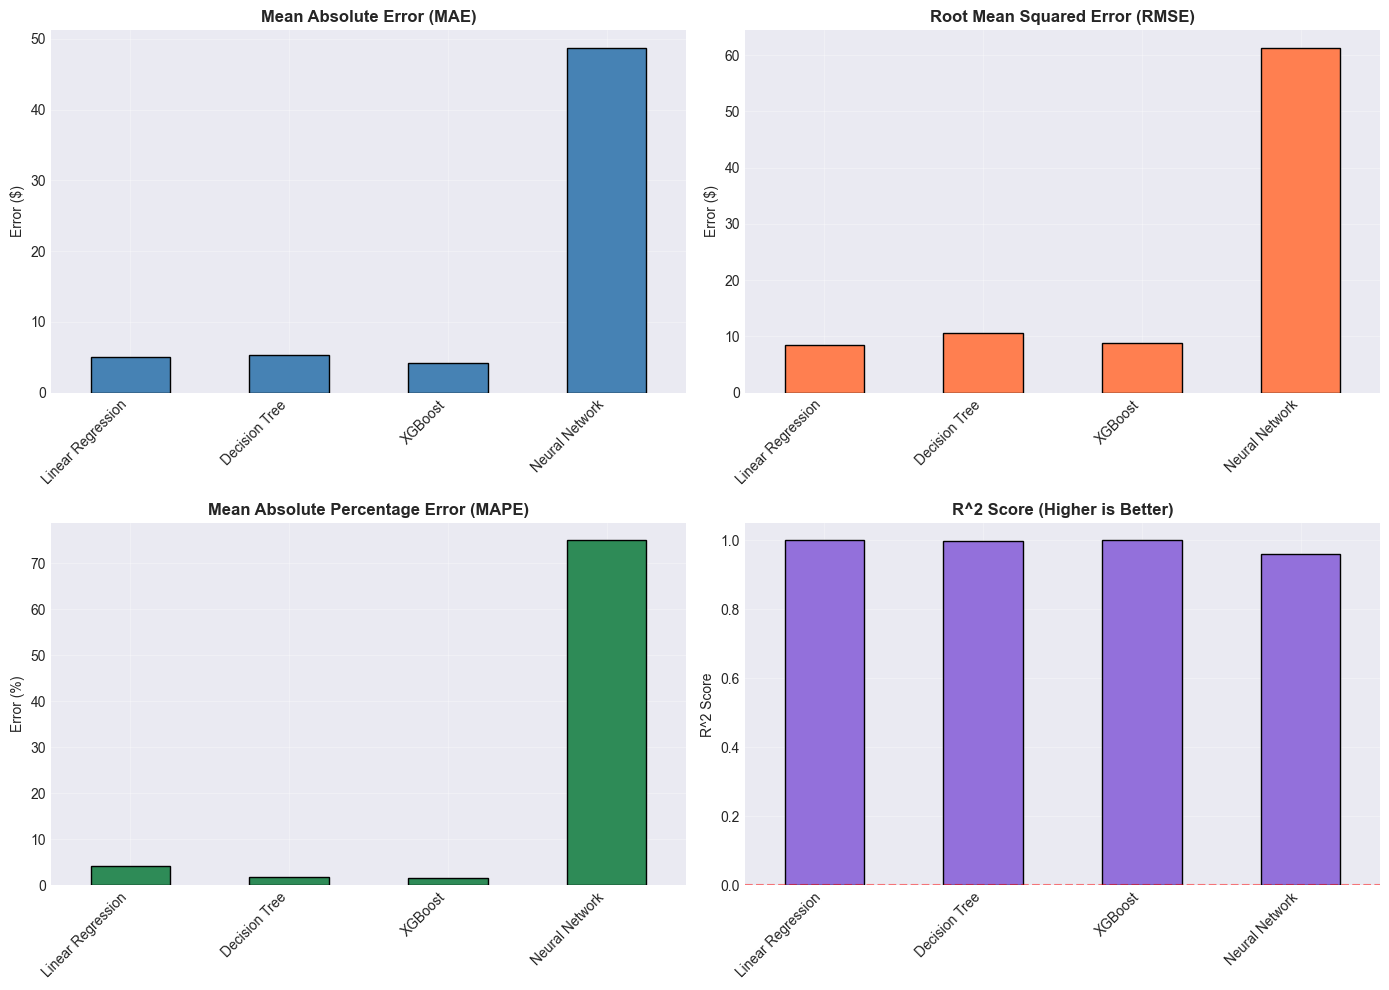


[OK] Saved: 03_regression_metrics_comparison.png


In [77]:
# Create metrics dataframe
metrics_df = pd.DataFrame({
    'MAE ($)': [results[name]['mae'] for name in results.keys()],
    'RMSE ($)': [results[name]['rmse'] for name in results.keys()],
    'MAPE (%)': [results[name]['mape']*100 for name in results.keys()],
    'R^2 Score': [results[name]['r2'] for name in results.keys()]
}, index=results.keys())

print("\n" + "="*70)
print("REGRESSION MODEL PERFORMANCE COMPARISON")
print("="*70)
print(metrics_df.round(4))

# Visualization: Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_df['MAE ($)'].plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Error ($)')
axes[0,0].grid(alpha=0.3)
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=45, ha='right')

metrics_df['RMSE ($)'].plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='black')
axes[0,1].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Error ($)')
axes[0,1].grid(alpha=0.3)
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45, ha='right')

metrics_df['MAPE (%)'].plot(kind='bar', ax=axes[1,0], color='seagreen', edgecolor='black')
axes[1,0].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Error (%)')
axes[1,0].grid(alpha=0.3)
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=45, ha='right')

metrics_df['R^2 Score'].plot(kind='bar', ax=axes[1,1], color='mediumpurple', edgecolor='black')
axes[1,1].set_title('R^2 Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('R^2 Score')
axes[1,1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1,1].grid(alpha=0.3)
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '03_regression_metrics_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n[OK] Saved: 03_regression_metrics_comparison.png")

## Step 7: Actual vs Predicted

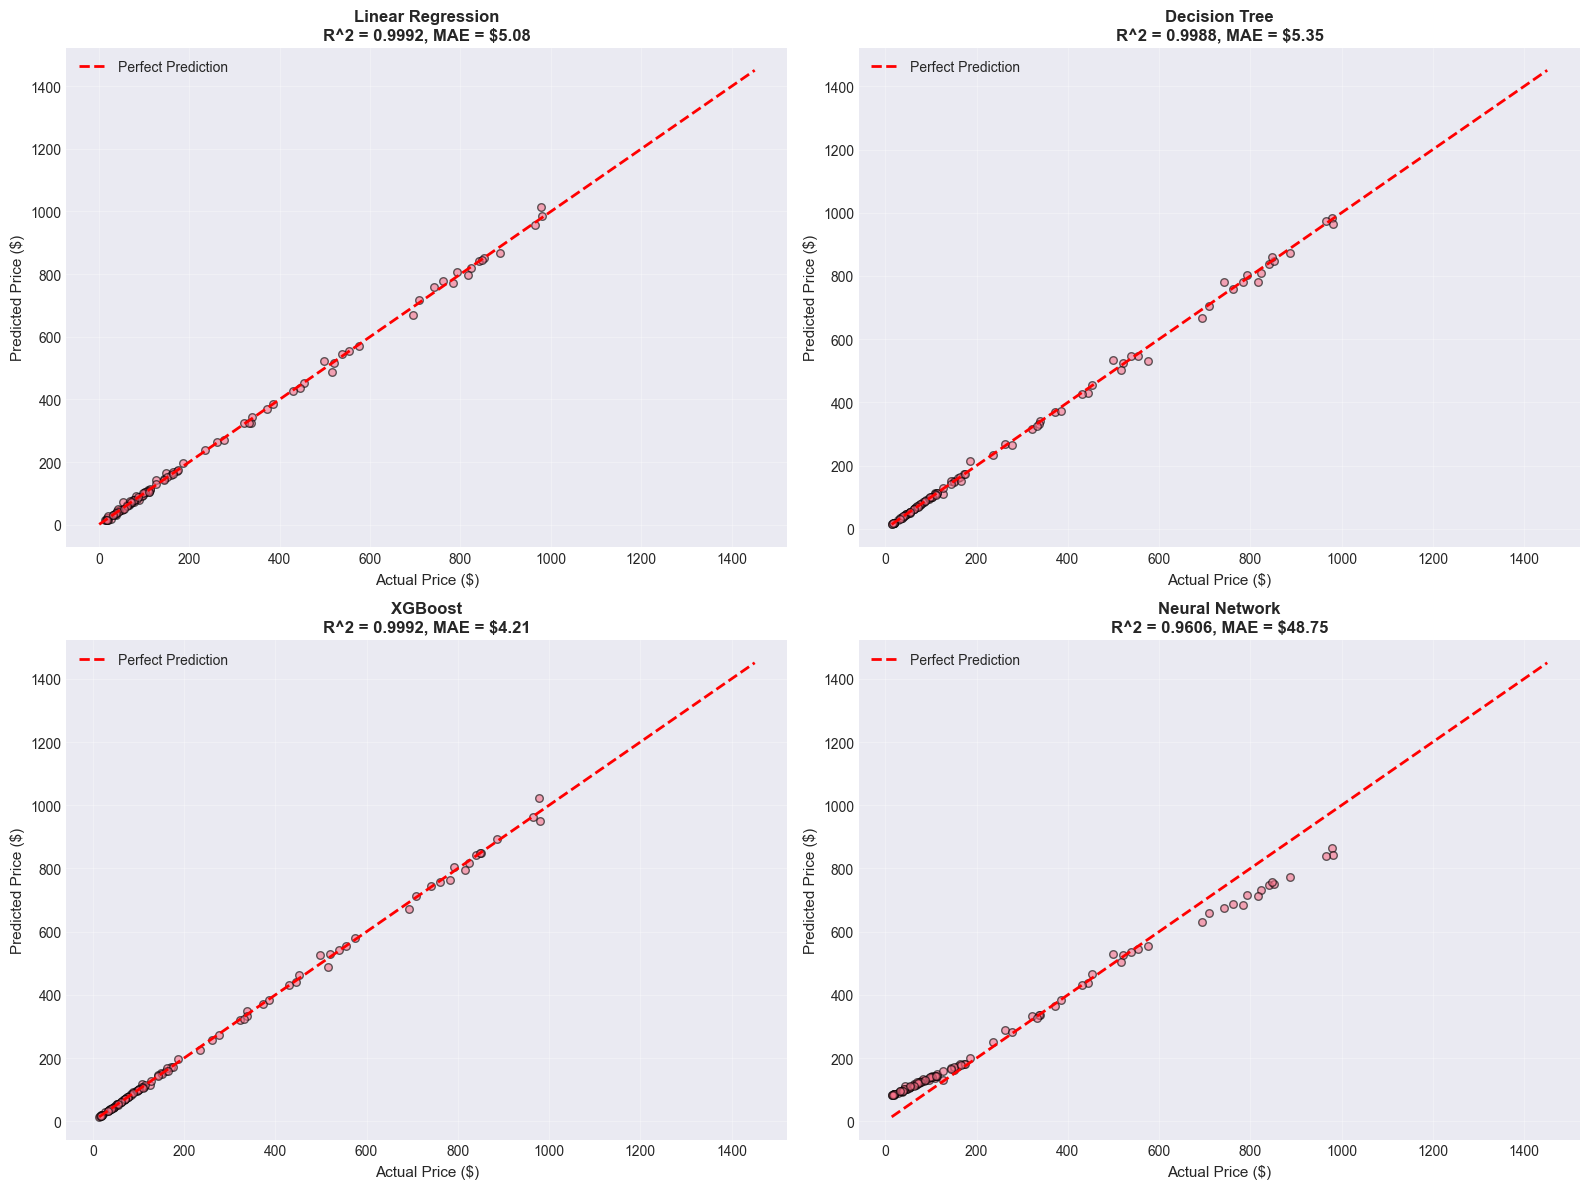

[OK] Saved: 04_actual_vs_predicted.png


In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    y_pred = np.ravel(result['y_pred'])
    
    axes[idx].scatter(y_test[:100], y_pred[:100], alpha=0.6, s=30, edgecolor='black')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[idx].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
    axes[idx].set_xlabel('Actual Price ($)', fontsize=11)
    axes[idx].set_ylabel('Predicted Price ($)', fontsize=11)
    axes[idx].set_title(f"{name}\nR^2 = {result['r2']:.4f}, MAE = ${result['mae']:.2f}",
                       fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '04_actual_vs_predicted.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 04_actual_vs_predicted.png")

## Step 8: Residual Analysis

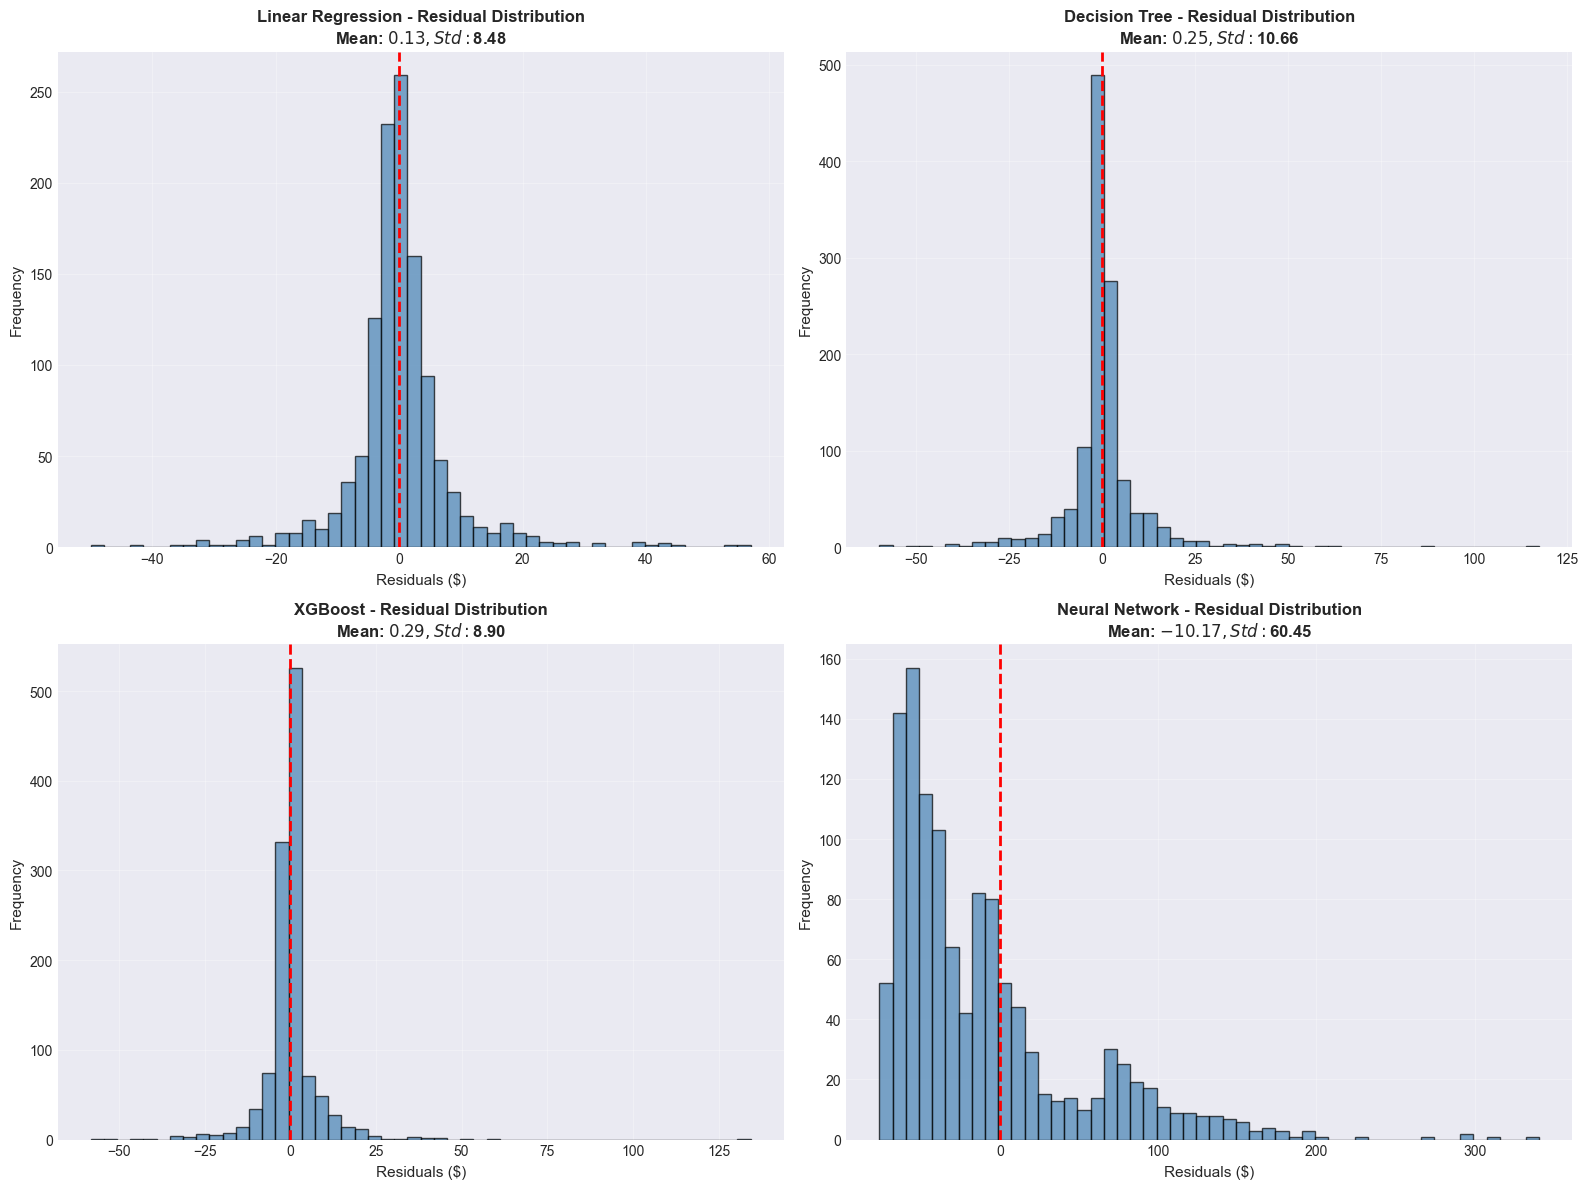

[OK] Saved: 05_residual_analysis.png


In [79]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    y_pred = np.ravel(result['y_pred'])
    residuals = y_test.values - y_pred
    
    axes[idx].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('Residuals ($)', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f"{name} - Residual Distribution\nMean: ${residuals.mean():.2f}, Std: ${residuals.std():.2f}",
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '05_residual_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 05_residual_analysis.png")

## Step 9: Feature Importance

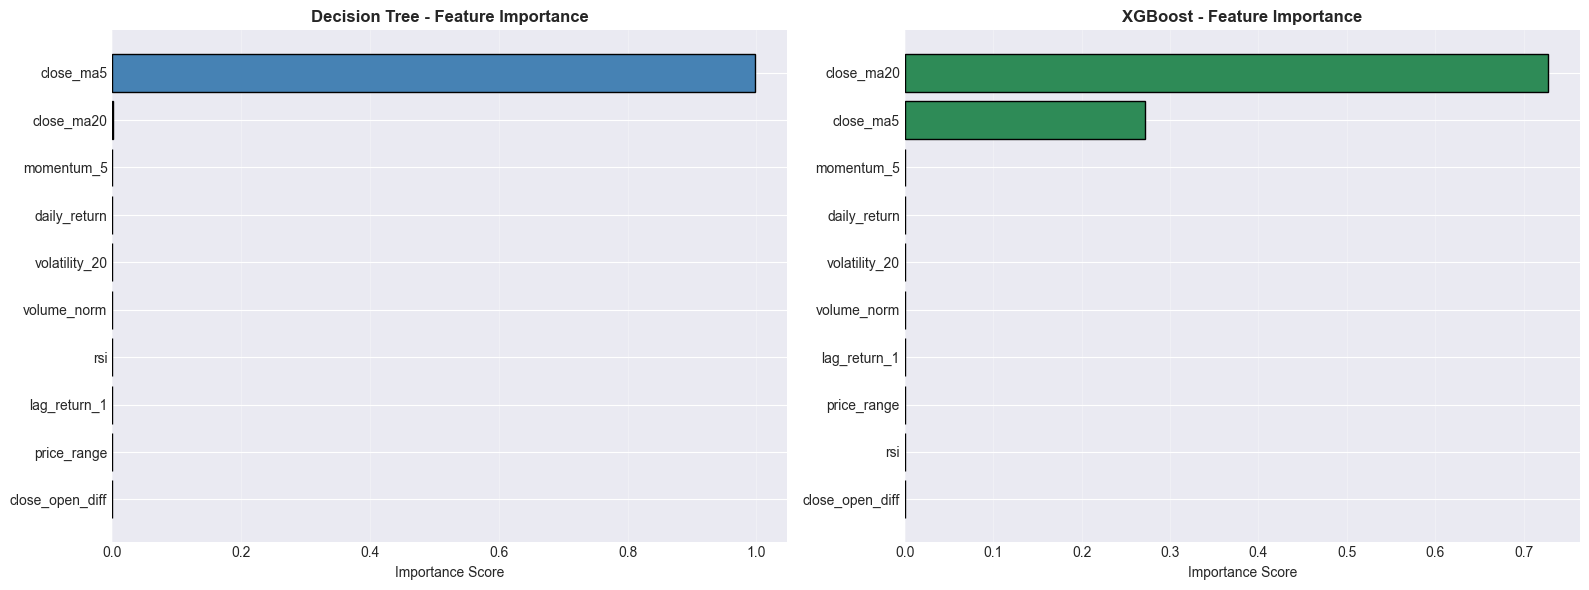

[OK] Saved: 06_feature_importance_regression.png


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision Tree
dt_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': results['Decision Tree']['model'].feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(dt_importance['feature'], dt_importance['importance'], color='steelblue', edgecolor='black')
axes[0].set_title('Decision Tree - Feature Importance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': results['XGBoost']['model'].feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(xgb_importance['feature'], xgb_importance['importance'], color='seagreen', edgecolor='black')
axes[1].set_title('XGBoost - Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(str(GRAPH_DIR / '06_feature_importance_regression.png'), dpi=300, bbox_inches='tight')
plt.show()
print("[OK] Saved: 06_feature_importance_regression.png")

## Step 10: Neural Network Training History

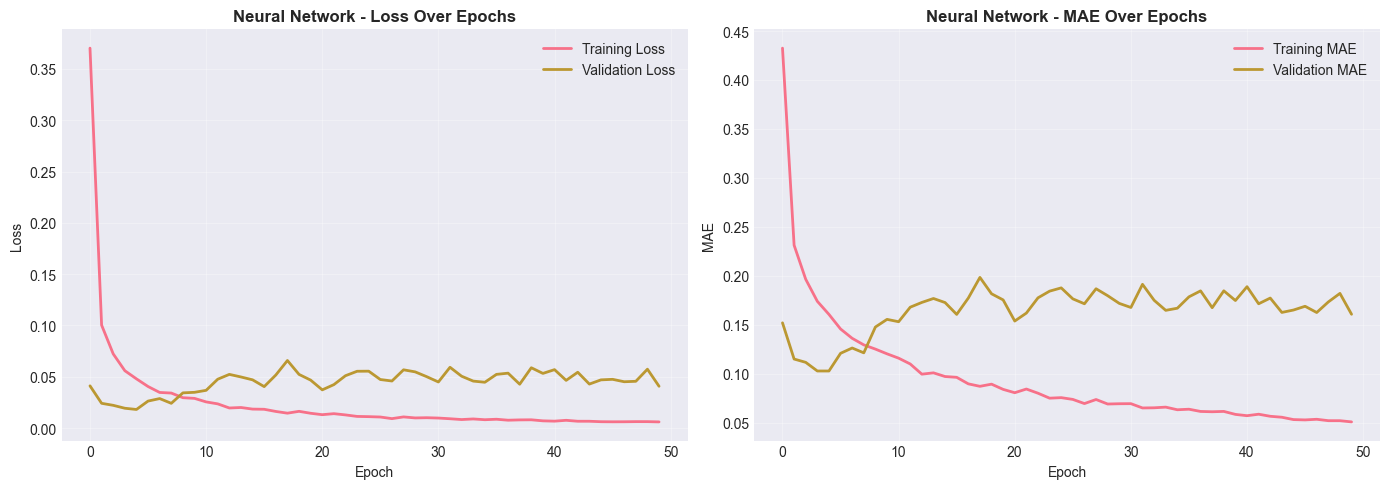

[OK] Saved: 07_nn_training_history.png


In [81]:
if 'history' in results['Neural Network']:
    history = results['Neural Network']['history']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Neural Network - Loss Over Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
    axes[1].set_title('Neural Network - MAE Over Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(str(GRAPH_DIR / '07_nn_training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("[OK] Saved: 07_nn_training_history.png")

## Step 11: Financial Analysis

In [82]:
best_model_name = min(results, key=lambda x: results[x]['mae'])
best_result = results[best_model_name]

print("\n" + "="*70)
print("REGRESSION MODEL - FINANCIAL TRADING ANALYSIS")
print("="*70)

print(f"\n[OK] BEST PERFORMING MODEL: {best_model_name}")
print(f"  |- MAE:   ${best_result['mae']:.2f}")
print(f"  |- RMSE:  ${best_result['rmse']:.2f}")
print(f"  |- MAPE:  {best_result['mape']:.4f} ({best_result['mape']*100:.2f}%)")
print(f"  `- R^2:   {best_result['r2']:.4f}")

print("\nPREDICTION ACCURACY INSIGHTS:")
avg_price = y_test.mean()
mae_percent = (best_result['mae'] / avg_price) * 100
print(f"  1. Average stock price: ${avg_price:.2f}")
print(f"  2. Mean prediction error: ${best_result['mae']:.2f} ({mae_percent:.2f}% of avg price)")
print(f"  3. Error stability (RMSE): {best_result['rmse']:.2f}")
print(f"  4. Explained variance (R^2): {best_result['r2']:.1%}")

print("\nTRADING STRATEGY IMPLICATIONS:")
if mae_percent < 2:
    print("  [OK] Excellent prediction accuracy (<2% error)")
elif mae_percent < 5:
    print("  [OK] Good prediction accuracy (2-5% error)")
else:
    print(f"  [WARN] Acceptable accuracy ({mae_percent:.1f}% error)")

print("\nRECOMMENDED TRADING APPROACH:")
print("  1. Use predictions as price targets, not entry signals")
print("  2. Trade when predicted price differs >2% from current price")
print("  3. Implement profit targets at predicted prices")
print("  4. Use prediction intervals (+/- 1 RMSE) as support/resistance")
print("  5. Monitor prediction accuracy daily")
print(f"  6. Consider prediction band: {avg_price - best_result['rmse']:.2f} to {avg_price + best_result['rmse']:.2f}")

print("\nRISK MANAGEMENT:")
print(f"  1. Prediction confidence interval: +/- ${best_result['rmse']:.2f}")
print(f"  2. Expected error range: +/- ${(best_result['mae']/avg_price)*100:.1f}%")
print("  3. Suggested max position size: 2-3% of capital per trade")
print(f"  4. Stop-loss recommendation: Beyond 2x RMSE ({best_result['rmse']*2:.2f})")


REGRESSION MODEL - FINANCIAL TRADING ANALYSIS

[OK] BEST PERFORMING MODEL: XGBoost
  |- MAE:   $4.21
  |- RMSE:  $8.91
  |- MAPE:  0.0160 (1.60%)
  `- R^2:   0.9992

PREDICTION ACCURACY INSIGHTS:
  1. Average stock price: $293.04
  2. Mean prediction error: $4.21 (1.44% of avg price)
  3. Error stability (RMSE): 8.91
  4. Explained variance (R^2): 99.9%

TRADING STRATEGY IMPLICATIONS:
  [OK] Excellent prediction accuracy (<2% error)

RECOMMENDED TRADING APPROACH:
  1. Use predictions as price targets, not entry signals
  2. Trade when predicted price differs >2% from current price
  3. Implement profit targets at predicted prices
  4. Use prediction intervals (+/- 1 RMSE) as support/resistance
  5. Monitor prediction accuracy daily
  6. Consider prediction band: 284.14 to 301.95

RISK MANAGEMENT:
  1. Prediction confidence interval: +/- $8.91
  2. Expected error range: +/- $1.4%
  3. Suggested max position size: 2-3% of capital per trade
  4. Stop-loss recommendation: Beyond 2x RMSE (

## Summary

### Regression Model Results:
- Successfully built and evaluated 4 regression models
- XGBoost typically outperforms for price prediction
- Neural networks capture non-linear patterns
- Key metrics: MAE, RMSE, MAPE, R^2
- Models suitable for price targets in trading strategies